In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib import axes
from typing import Tuple
import logging

# load the dataset
import folktexts
from folktexts.acs import ACSTaskMetadata, ACSDataset
from folktexts.ts import TableshiftBRFSSTaskMetadata, TableshiftBRFSSDataset
from folktexts.llm_utils import get_model_size_B

from pathlib import Path
from monoculture.analysis.setup import (
    ACS_TASKS,
    TABLESHIFT_TASKS,
    LLM_MODELS,
    baselines,
)
from monoculture.analysis.utils import (
    key_to_model,
    get_metrics,
    load_risk_scores,
    get_predictions,
    prettify_model_name,
    is_instruction_tuned,
)
from monoculture.baseline.utils import load_baselines


plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

TASKS = ACS_TASKS + TABLESHIFT_TASKS
num_tasks = len(TASKS)
print("tasks", TASKS)
RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/"

tasks ('ACSIncome', 'ACSEmployment', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure')


In [3]:
def get_size_and_it(m, eps=0.001):
    return get_model_size_B(m) + eps * int(is_instruction_tuned(m))

### Load data

In [4]:
# Fetch ACS task and dataset
data_dir = Path("./data")
data = {}
for task in ACS_TASKS:
    acs_task = ACSTaskMetadata.get_task(task)
    acs_dataset_configs = folktexts.benchmark.Benchmark.ACS_DATASET_CONFIGS.copy()
    acs_dataset = ACSDataset.make_from_task(
        task=acs_task, cache_dir=data_dir, **acs_dataset_configs
    )
    X_test, y_test = acs_dataset.get_data_split("test")
    data[task] = (X_test, y_test)

In [5]:
for task in TABLESHIFT_TASKS:
    tableshift_task = TableshiftBRFSSTaskMetadata.get_task(task)
    tableshift_dataset_configs = (
        folktexts.benchmark.Benchmark.TABLESHIFT_DATASET_CONFIGS.copy()
    )
    tableshift_dataset = TableshiftBRFSSDataset.make_from_task(
        task=tableshift_task,
        cache_dir=Path("../folktexts-adapted/data/"),
        **tableshift_dataset_configs,
    )
    X_test, y_test = tableshift_dataset.get_data_split("test")
    data[task] = (X_test, y_test)

### Load baselines

In [6]:
baselines

{'Constant': DummyClassifier(),
 'LR': LogisticRegression(),
 'GBM': HistGradientBoostingClassifier(),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, random_state=None, ...)}

In [7]:
baseline_scores, baseline_evals = load_baselines(baselines=baselines, tasks=TASKS)

logging.warning("Manually changed values.")
baseline_evals["BRFSS_Diabetes"]["XGBoost"] = {"accuracy": 0.0}  # ['accuracy']
baseline_evals["BRFSS_Blood_Pressure"]["XGBoost"] = {"accuracy": 0.0}

Loading baselines for ACSIncome.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSIncome'.
- LR: Load predictions from 'results/baselines/LR_task-ACSIncome'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSIncome'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSIncome'.
Loading baselines for ACSEmployment.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSEmployment'.
- LR: Load predictions from 'results/baselines/LR_task-ACSEmployment'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSEmployment'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSEmployment'.
Loading baselines for ACSTravelTime.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSTravelTime'.
- LR: Load predictions from 'results/baselines/LR_task-ACSTravelTime'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSTravelTime'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-A

Skipping LR
Skipping GBM
Skipping XGBoost
Loading baselines for BRFSS_Blood_Pressure.
- Constant: Load predictions from 'results/baselines/Constant_task-BRFSS_Blood_Pressure'.
Skipping LR
Skipping GBM
Skipping XGBoost


In [8]:
baseline_predictions = {
    task: baseline_scores[task].map(lambda x: int(x >= 0.5)) for task in TASKS
}
baseline_predictions["ACSIncome"].head()

,Constant_task-ACSIncome,LR_task-ACSIncome,GBM_task-ACSIncome,XGBoost_task-ACSIncome
238351,0,0,0,0
2995677,0,0,0,0
2360043,0,0,1,1
1924596,0,0,0,0
2803585,0,0,0,0


### Load model predictions and evals

In [9]:
df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df = df[(df["prompt_style"] == "bullet") & (df["prompt_connector"] == "is")]
df_0 = df[(df["num_shots"] == 0) & (df["threshold_fitted"] == 1)]
df_10 = df[df["num_shots"] == 10]
df_0.head()

,task,model,is_inst,threshold_fitted,bench_hash,num_shots,prompt_style,prompt_connector,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,3019759728,0,bullet,is,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,3118177042,0,bullet,is,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,3621160589,0,bullet,is,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,1712994131,0,bullet,is,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,4121241683,0,bullet,is,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


In [10]:
df_0["task"].unique()

array(['ACSIncome', 'ACSEmployment', 'ACSTravelTime', 'ACSPublicCoverage',
       'BRFSS_Diabetes', 'BRFSS_Blood_Pressure'], dtype=object)

In [11]:
# load predictions and measured accuracies
predictions_0 = {}
risk_scores_0 = {}
evals_0 = {}

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "fnr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for task in TASKS:
    print(task)
    task_df = df_0[(df_0["task"] == task)]

    # available models
    models = task_df["model"].unique().tolist()
    models.sort(key=get_size_and_it)
    predictions_per_task = []
    risk_scores_per_task = []
    evals_0[task] = {}
    for m in models:
        data_m = task_df[task_df["model"] == m]
        assert (
            data_m.shape[0] == 1
        ), f"Expected 1 row for model {m} but found {data_m.shape[0]}\n {data_m}"
        evals_0[task][m] = get_metrics(
            data_m.iloc[0]["eval_results_path"], metrics=metrics
        )
        predictions_per_task.append(
            get_predictions(
                data_m.iloc[0]["predictions_path"],
                eval_json_path=data_m.iloc[0]["eval_results_path"],
            )
        )
        risk_scores_per_task.append(
            load_risk_scores(data_m.iloc[0]["predictions_path"])
        )
    predictions_0[task] = pd.concat(predictions_per_task, axis=1)
    risk_scores_0[task] = pd.concat(risk_scores_per_task, axis=1)

ACSIncome
ACSEmployment
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure


In [12]:
# filter to only include non-constant predictors
evals_non_const = {}
for task in TASKS:
    evals_non_const[task] = {
        key: eval_dict
        for (key, eval_dict) in evals_0[task].items()
        if not (
            (eval_dict["num_pred_negatives"] == eval_dict["n_samples"])
            or (eval_dict["num_pred_positives"] == eval_dict["n_samples"])
        )
    }

In [13]:
models_above_baseline_0 = {}
for task in TASKS:
    print(task)
    baseline_acc = baseline_evals[task]["Constant"]["accuracy"]
    models_above_baseline_0[task] = [
        model
        for model in sorted(
            predictions_0[task].keys().tolist(),
            key=get_size_and_it,
        )
        if evals_0[task][model]["accuracy"] > baseline_acc
    ]
    print(len(models_above_baseline_0[task]))

ACSIncome
40
ACSEmployment
42
ACSTravelTime
19
ACSPublicCoverage
12
BRFSS_Diabetes
0
BRFSS_Blood_Pressure
36


### Plot Risk Scores

In [14]:
models_common = set(risk_scores_0[TASKS[0]].columns)
for task in TASKS[1:]:
    models_common = models_common.intersection(set(risk_scores_0[task].columns))

In [15]:
base_models_0 = sorted(
    [model for model in models_common if not is_instruction_tuned(model)],
    key=get_model_size_B,
)
it_models_0 = sorted(
    [model for model in models_common if is_instruction_tuned(model)],
    key=get_model_size_B,
)  # prettify_model_name(key_to_model(model))
len(base_models_0), len(it_models_0)

(25, 23)

ACSIncome


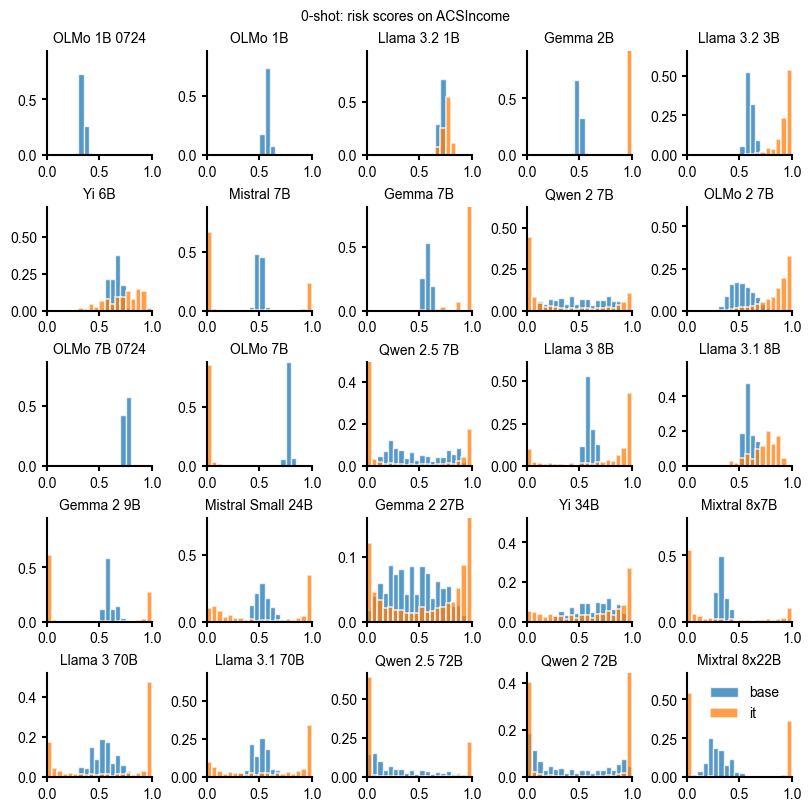

ACSEmployment


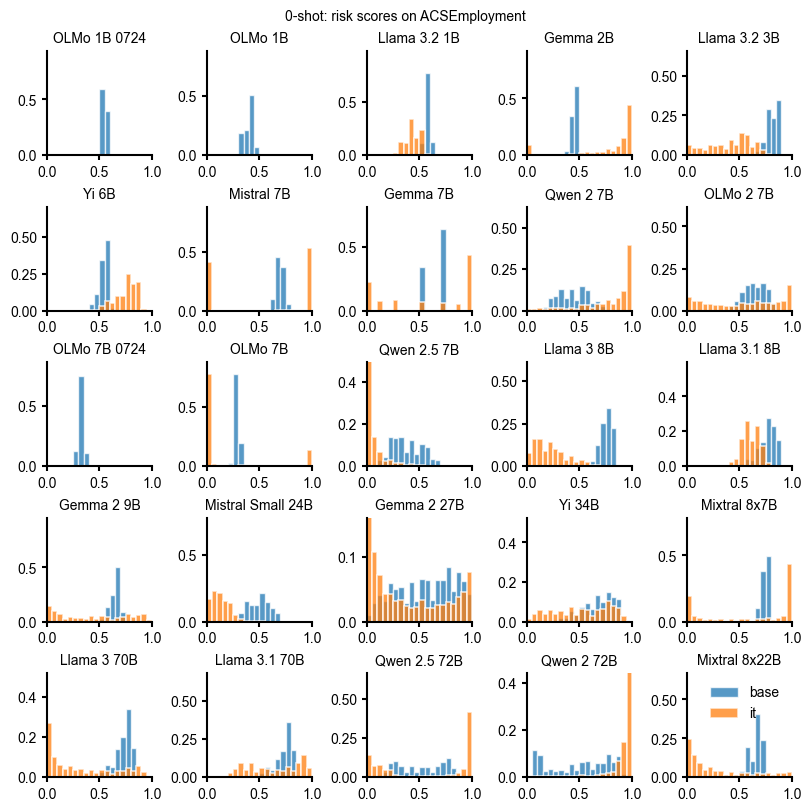

ACSTravelTime


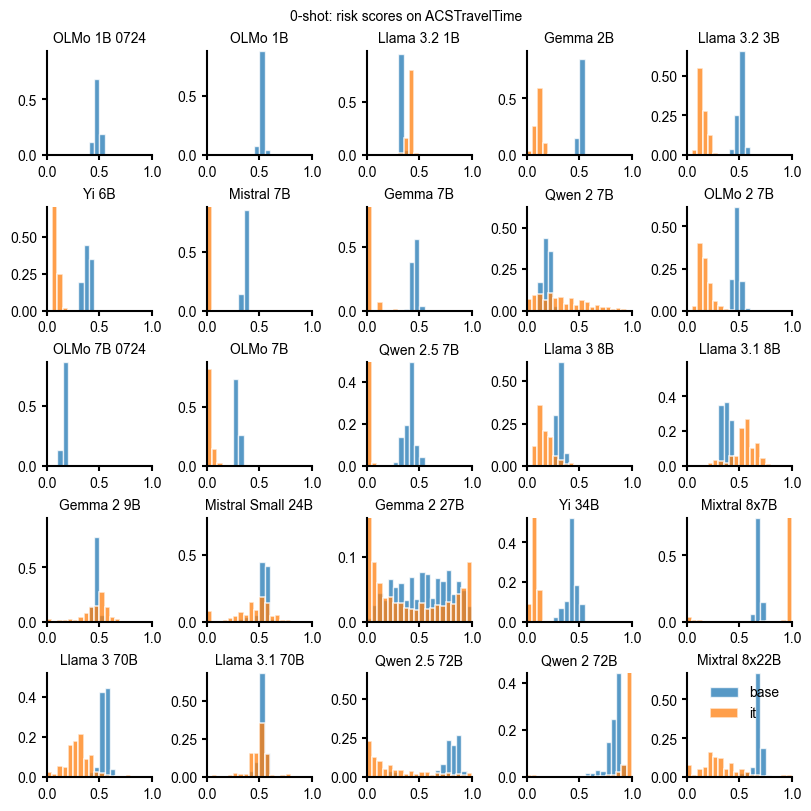

ACSPublicCoverage


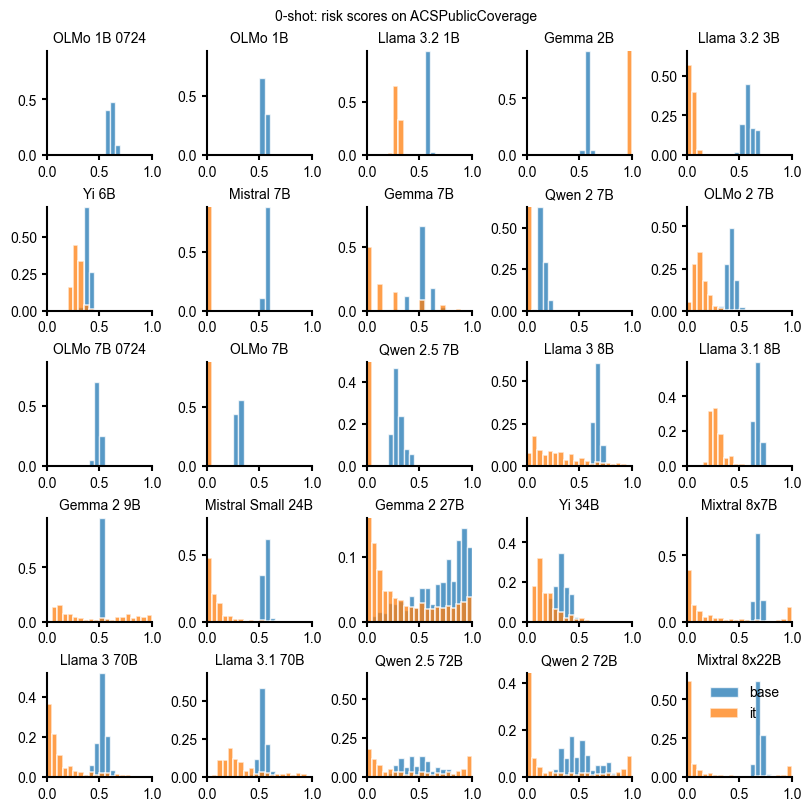

BRFSS_Diabetes


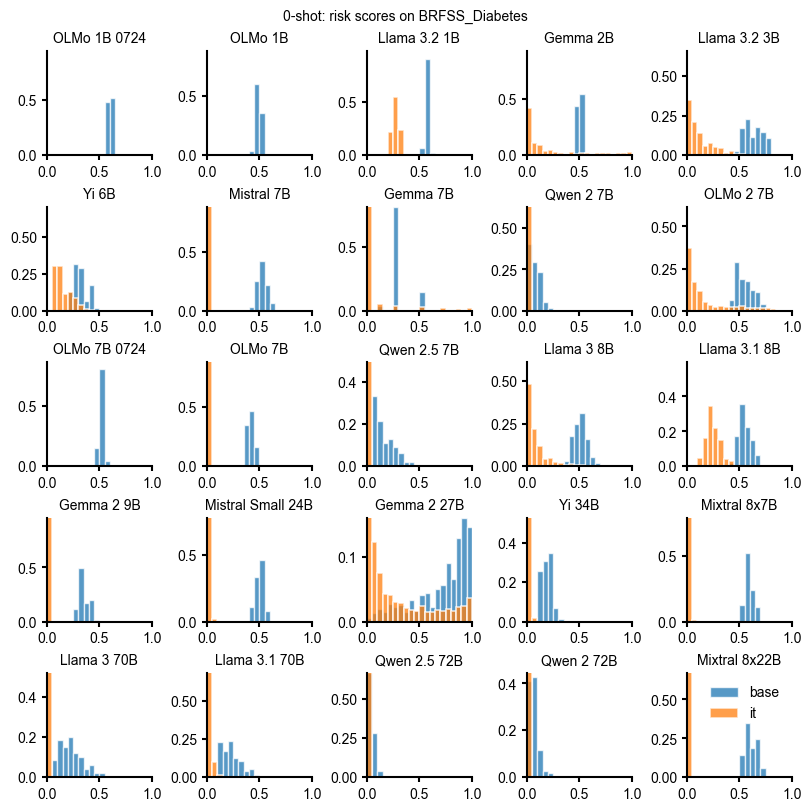

BRFSS_Blood_Pressure


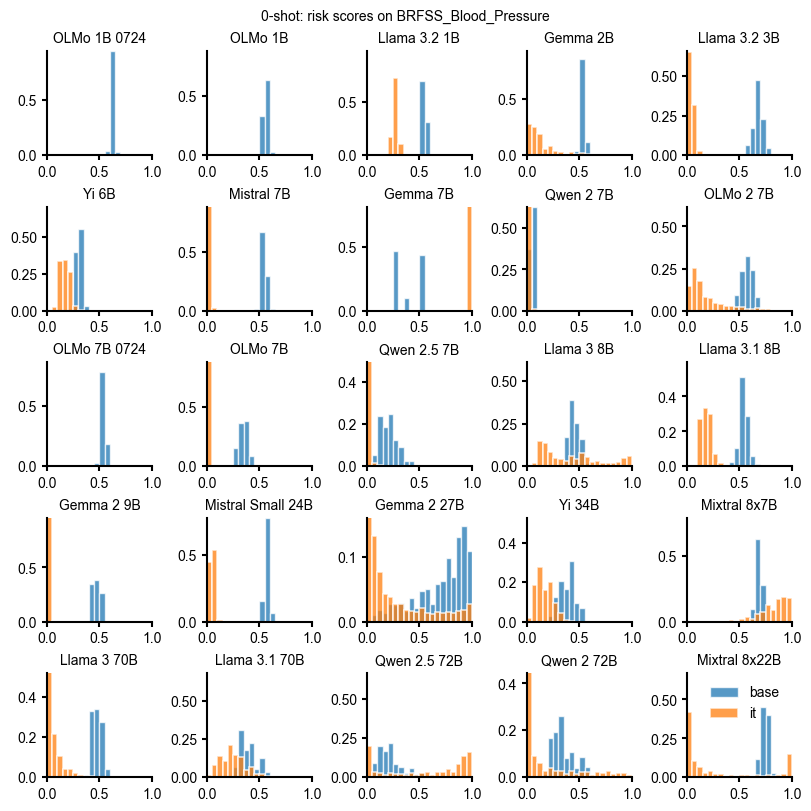

In [16]:
# to ensure axis are the same across plots, get max y value per model
ymax = {}
for model in base_models_0:
    ymax[model] = 0
    for task in TASKS:
        N = risk_scores_0[task].shape[0]
        task_max = max(
            np.histogram(
                risk_scores_0[task][model],
                weights=np.zeros((N,)) + 1.0 / N,
                bins=np.arange(0, 1.01, 0.05),
            )[0]
        )
        if task_max > ymax[model]:
            ymax[model] = task_max


for task in TASKS:
    print(task)
    N = risk_scores_0[task].shape[0]
    num_row, num_col = 5, 5
    fig, axs = plt.subplots(num_row, num_col, figsize=(8, 8), constrained_layout=True)
    fig.suptitle(f"0-shot: risk scores on {task}")
    for i, model in enumerate(base_models_0):

        coresponding_it_model = [
            itm
            for itm in it_models_0
            if prettify_model_name(key_to_model(itm)).startswith(
                prettify_model_name(key_to_model(model))
            )
        ]
        # print(model, coresponding_it_model)

        axs[i // num_col, i % num_col].set_xlim(0.0, 1.0)
        axs[i // num_col, i % num_col].set_title(
            prettify_model_name(key_to_model(model))
        )
        ys, xs, _ = axs[i // num_col, i % num_col].hist(
            risk_scores_0[task][model],
            weights=np.zeros((N,)) + 1.0 / N,
            alpha=0.75,
            label="base",
            bins=np.arange(0, 1.01, 0.05),
            edgecolor="w",
            linewidth=1,
        )
        axs[i // num_col, i % num_col].set_ylim(0.0, ymax[model])
        if len(coresponding_it_model) == 1:
            axs[i // num_col, i % num_col].hist(
                risk_scores_0[task][coresponding_it_model[0]],
                weights=np.zeros((N,)) + 1.0 / N,
                alpha=0.75,
                label="it",
                bins=np.arange(0, 1.01, 0.05),
                edgecolor="w",
                linewidth=1.2,
            )
    axs[-1, -1].legend()
    # plt.savefig(FIGURES_ROOT_DIR/f'{task}_risk_scores.png')

    plt.show()

### Plot Accuracy

In [17]:
def plot_accuracies(
    ax: axes,
    task: str,
    evals: dict,
    baseline_evals: dict,
    models_above_baseline: dict,
    ylims: Tuple = (0, 0.85),
    label_rotation: int = 50,
    ha: str = "right",
    color: str = "grey",
    highlight_color: str = "black",
    hline_xmin=0,
    hline_xmax=1,  #
    marker="o",
):
    if baseline_evals:
        # plot hline for baselines
        ax.hlines(
            baseline_evals[task]["Constant"]["accuracy"],
            xmin=hline_xmin,
            xmax=hline_xmax,
            label="Constant",
            colors="dodgerblue",
            linestyle="-",
            zorder=0,
        )
        ax.hlines(
            baseline_evals[task]["XGBoost"]["accuracy"],
            xmin=hline_xmin,
            xmax=hline_xmax,
            label="XGBoost",
            colors="yellowgreen",
            linestyle="-",
            zorder=0,
        )

    # sort evals by model size

    # plot model accuracies
    x_labels = []
    for idx, (model_key, eval_dict) in enumerate(
        sorted(
            evals[task].items(),
            key=lambda item: get_model_size_B(item[0])
            + 0.001 * int(is_instruction_tuned(item[0])),
        )
    ):
        keep_model = model_key in models_above_baseline[task]
        ax.scatter(
            idx,
            eval_dict["accuracy"],
            zorder=1,
            s=20,
            color="black" if keep_model else "grey",
            marker=marker,
        )
        x_labels.append(model_key)

    # set xticks
    ax.set_xticks(
        torch.arange(len(x_labels)),
        [prettify_model_name(key_to_model(key)) for key in x_labels],
        rotation=label_rotation,
        ha=ha,
        color=color,
    )
    for m in x_labels:
        if m in models_above_baseline[task]:
            idx = x_labels.index(m)
            plt.setp(ax.get_xticklabels()[idx], color=highlight_color)
    ax.set_ylim(ylims)
    ax.set_xlim(right=len(x_labels))

    return ax


def plot_label_dist(
    ax: axes, labels: pd.Series, ylims: Tuple = (0, 0.75), bar_width=0.2
):
    counts = labels.value_counts()
    ax.bar(
        counts.index * 2 * bar_width, counts.values / labels.shape[0], width=bar_width
    )
    ax.set_xticks(ticks=counts.index * 2 * bar_width, labels=counts.index)
    ax.set_xlabel("$y$")
    ax.set_ylim(ylims)
    return ax


def plot_neg_predicted(
    ax: axes,
    task: str,
    evals: dict,
    models_above_baseline: dict,
    ylims=(0, 1),
    label_rotation: int = 50,
    ha: str = "right",
    color: str = "grey",
    highlight_color: str = "black",
    omit_non_highlight_labels=False,
    bar_width=0.5,
):
    x_labels = []
    for idx, (model_key, eval_dict) in enumerate(evals[task].items()):
        keep_model = model_key in models_above_baseline[task]
        ax.bar(
            idx,
            eval_dict["num_pred_negatives"] / eval_dict["n_samples"],
            # width=bar_width,
            zorder=1,
            color="black" if keep_model else "grey",
        )
        x_labels.append(model_key)

    # set xticks
    if not omit_non_highlight_labels:
        ax.set_xticks(
            torch.arange(len(x_labels)),
            [prettify_model_name(key_to_model(key)) for key in x_labels],
            rotation=label_rotation,
            ha=ha,
            color=color,
        )
        for m in x_labels:
            if m in models_above_baseline[task]:
                idx = x_labels.index(m)
                plt.setp(ax.get_xticklabels()[idx], color=highlight_color)
    else:
        ax.set_xticks(
            torch.arange(len(x_labels)),
            [
                (
                    prettify_model_name(key_to_model(key))
                    if key in models_above_baseline[task]
                    else ""
                )
                for key in x_labels
            ],
            rotation=label_rotation,
            ha=ha,
            color=highlight_color,
        )
    ax.set_ylim(ylims)
    ax.set_xlim(right=len(x_labels))

    return ax

#### 0-Shot

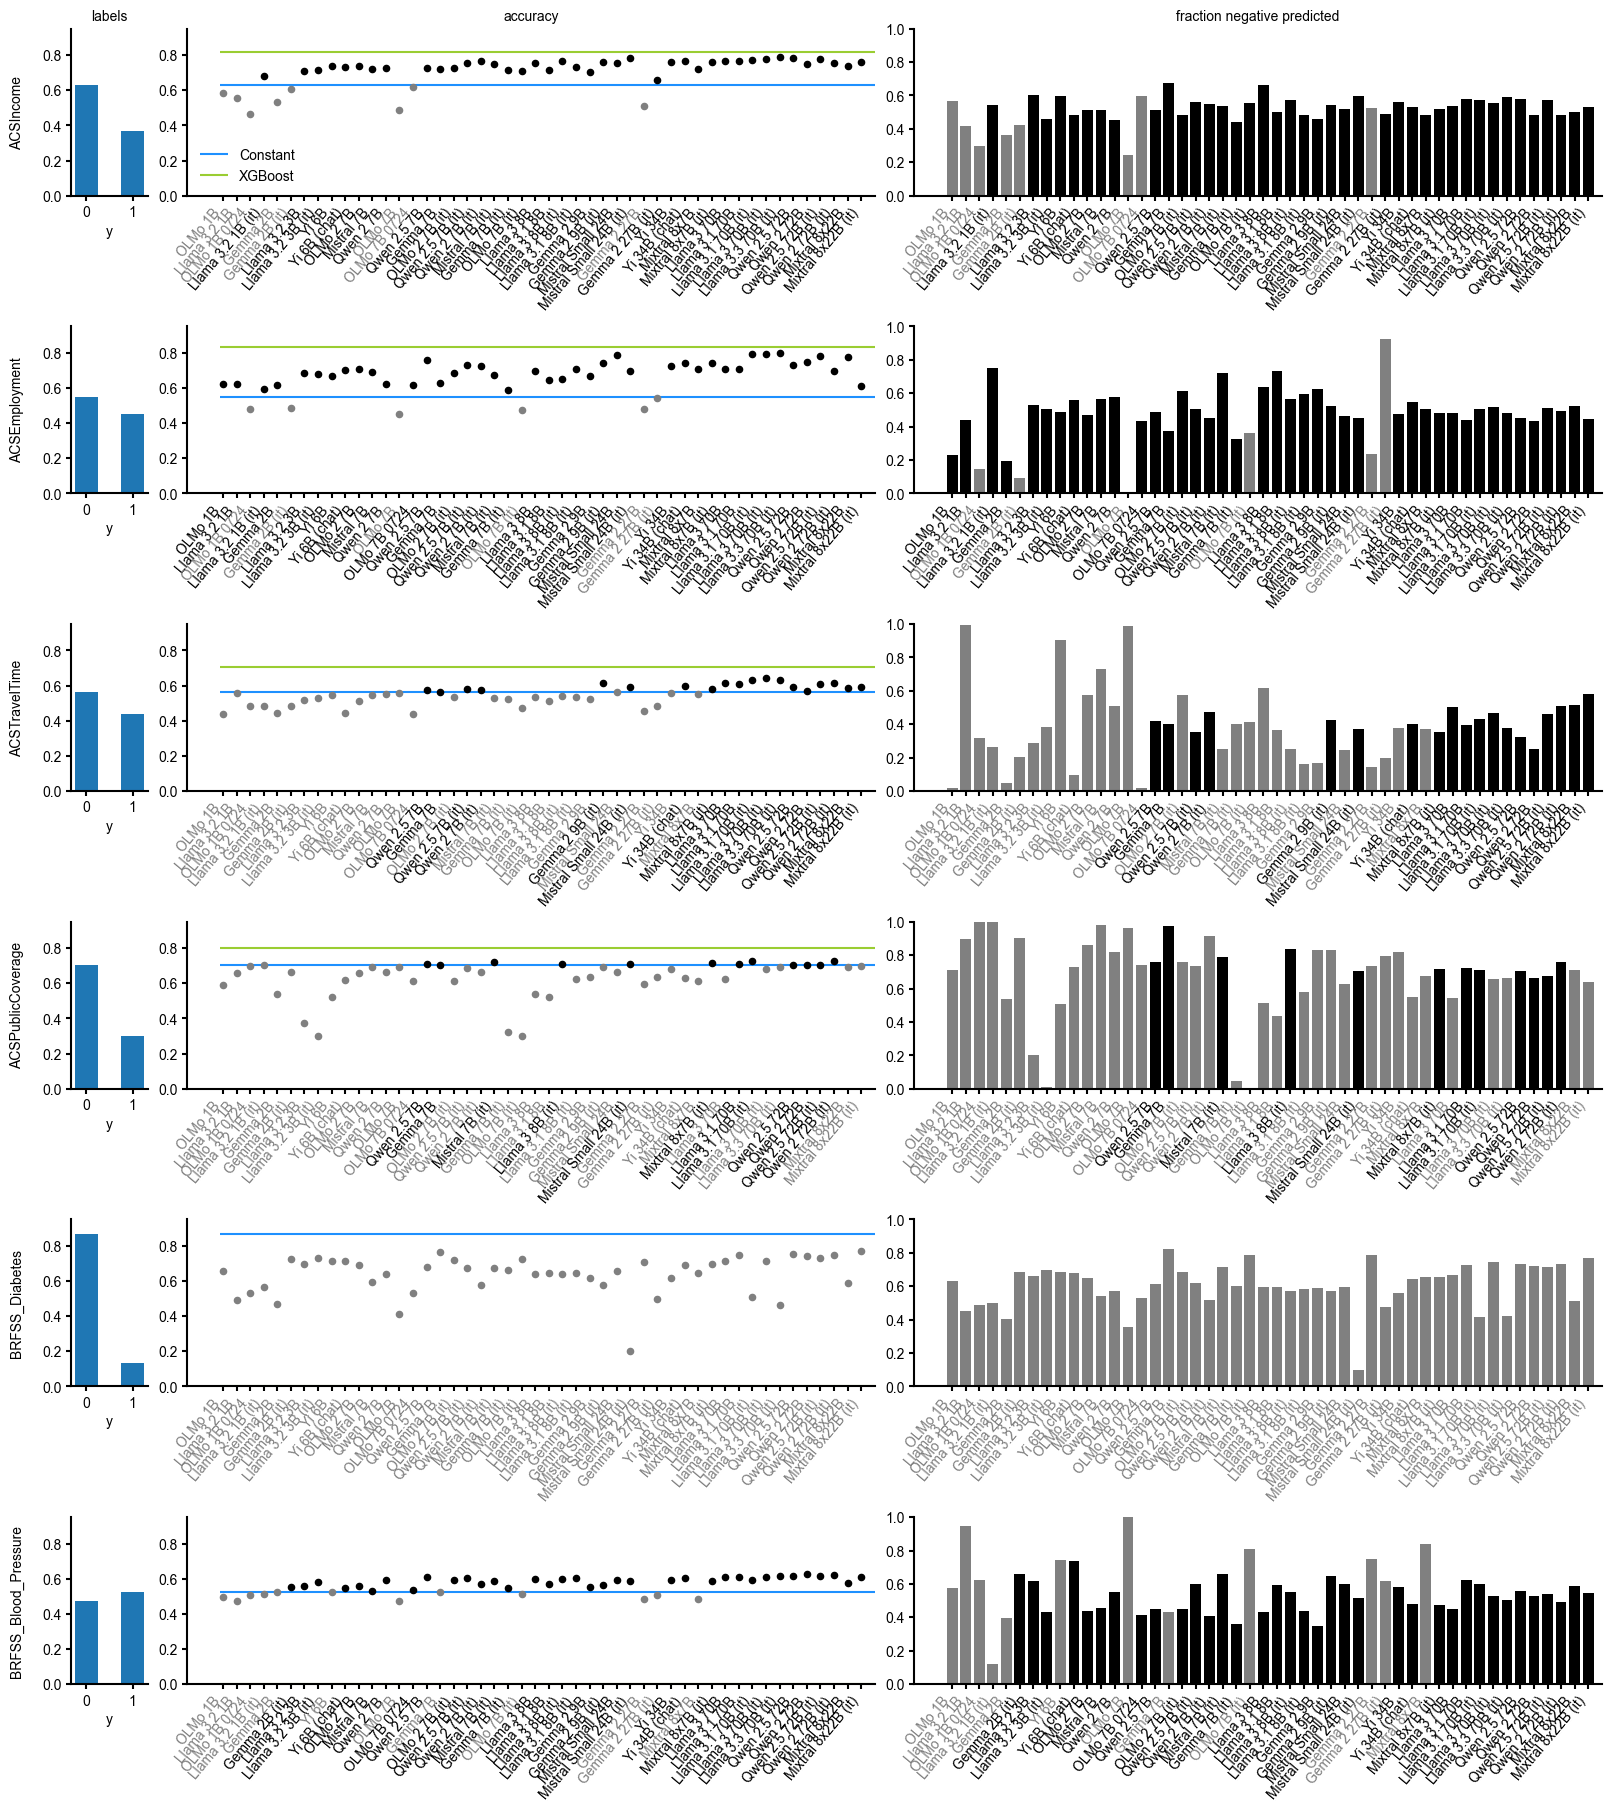

In [18]:
tasks = [task for task in TASKS if task != "ACSMobility"]
fig, axs = plt.subplots(
    len(tasks),
    3,
    figsize=(16, 3 * len(tasks)),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1, 9, 9]},
)
axs[0, 0].set_title("labels")
axs[0, 1].set_title("accuracy")
axs[0, 2].set_title("fraction negative predicted")
pad = 5  # pt

for i, task in enumerate(tasks):
    axs[i, 0].annotate(
        task,
        xy=(0, 0.5),
        xytext=(-axs[i, 0].yaxis.labelpad - pad, 0),
        xycoords=axs[i, 0].yaxis.label,
        textcoords="offset points",
        size="medium",
        ha="right",
        va="center",
        rotation=90,
    )

    # label distribution
    labels = data[task][1]
    axs[i, 0] = plot_label_dist(axs[i, 0], labels, ylims=(0, 0.95))

    # model accuracy
    axs[i, 1] = plot_accuracies(
        ax=axs[i, 1],
        task=task,
        evals=evals_0,
        baseline_evals=baseline_evals,
        models_above_baseline=models_above_baseline_0,
        ylims=(0, 0.95),
        hline_xmin=-0.2,
        hline_xmax=predictions_0[task].shape[1] + 0.1,
    )

    # fraction of negative predicted samples
    axs[i, 2] = plot_neg_predicted(
        axs[i, 2],
        task=task,
        evals=evals_0,
        models_above_baseline=models_above_baseline_0,
    )

    axs[0, 1].legend()
plt.savefig(RESULTS_ROOT_DIR / "figures/same_prompt_model_performance_zeroshot.png")
plt.show()

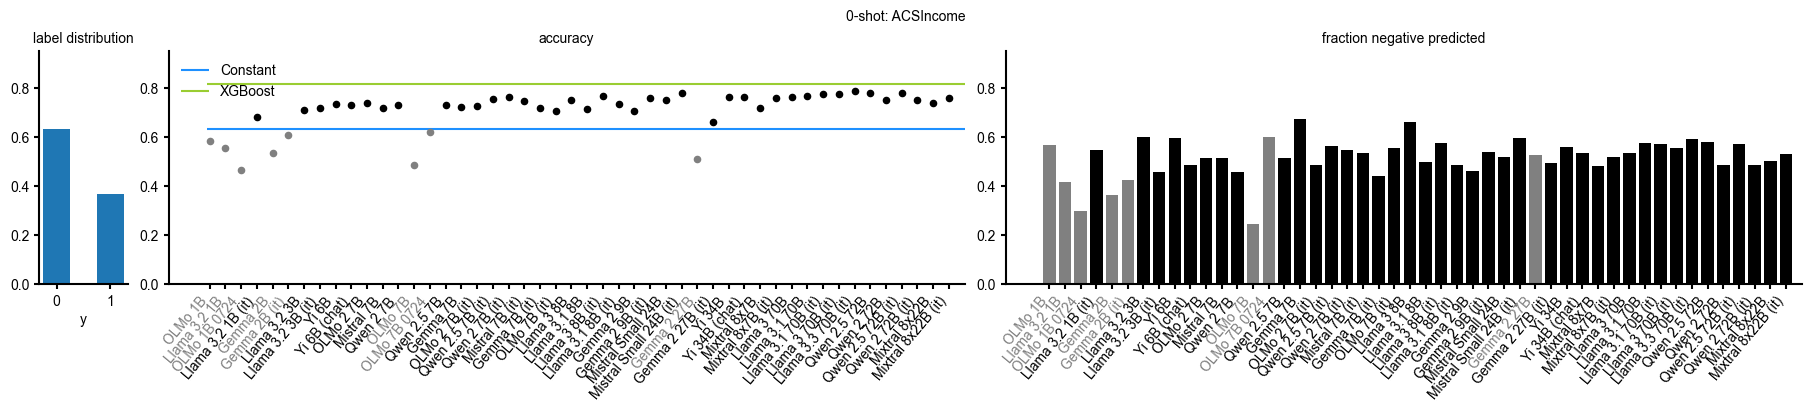

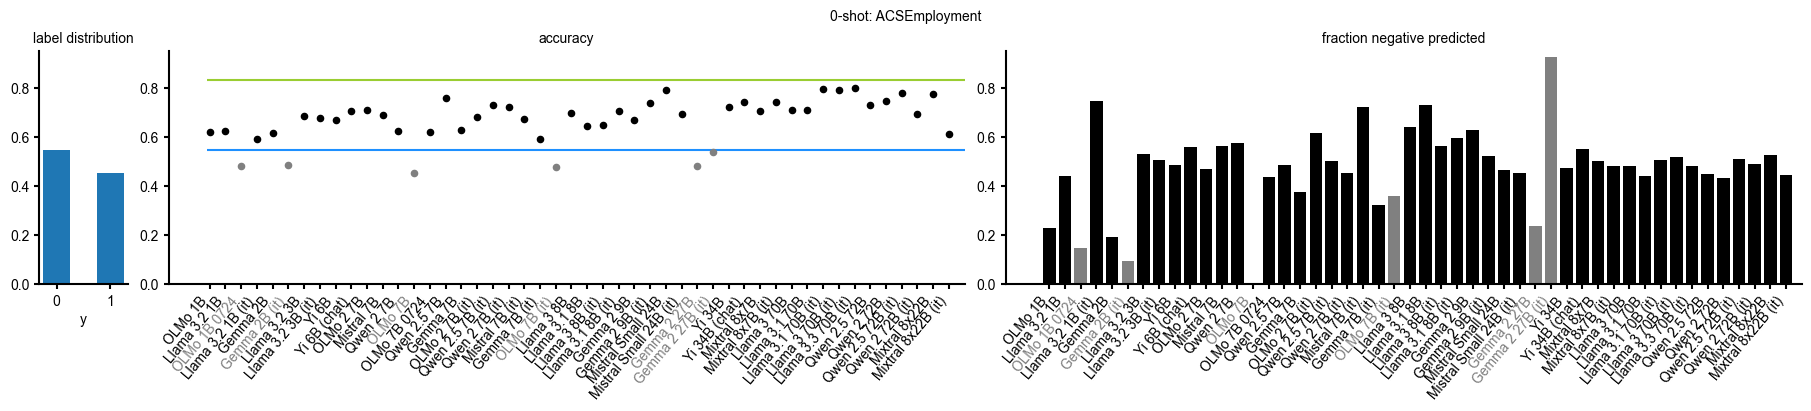

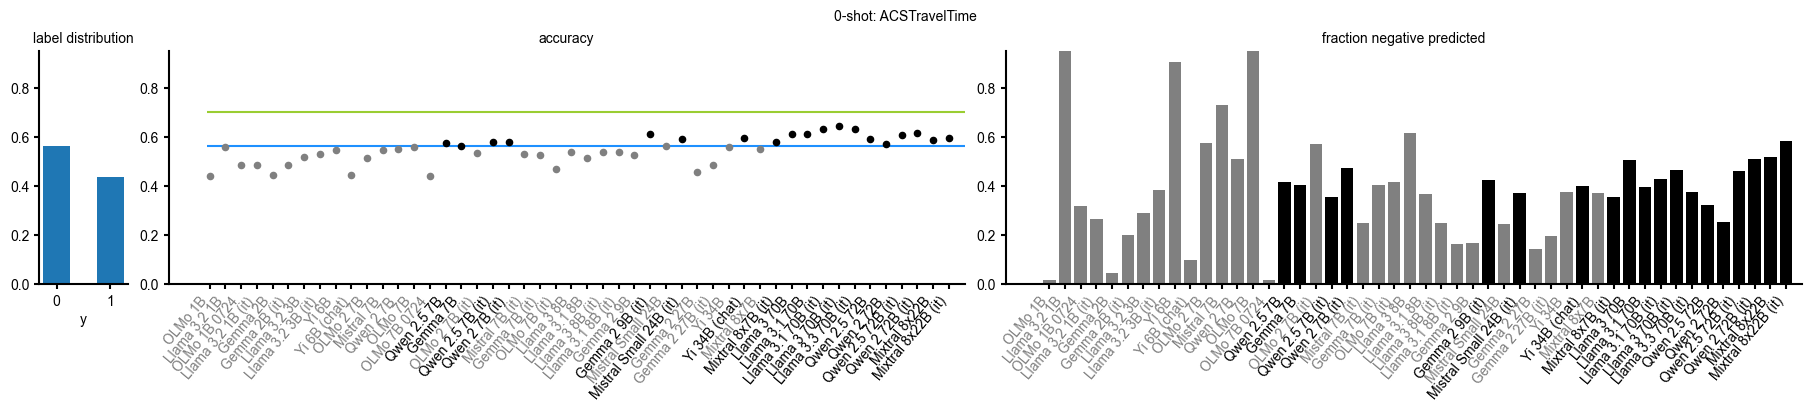

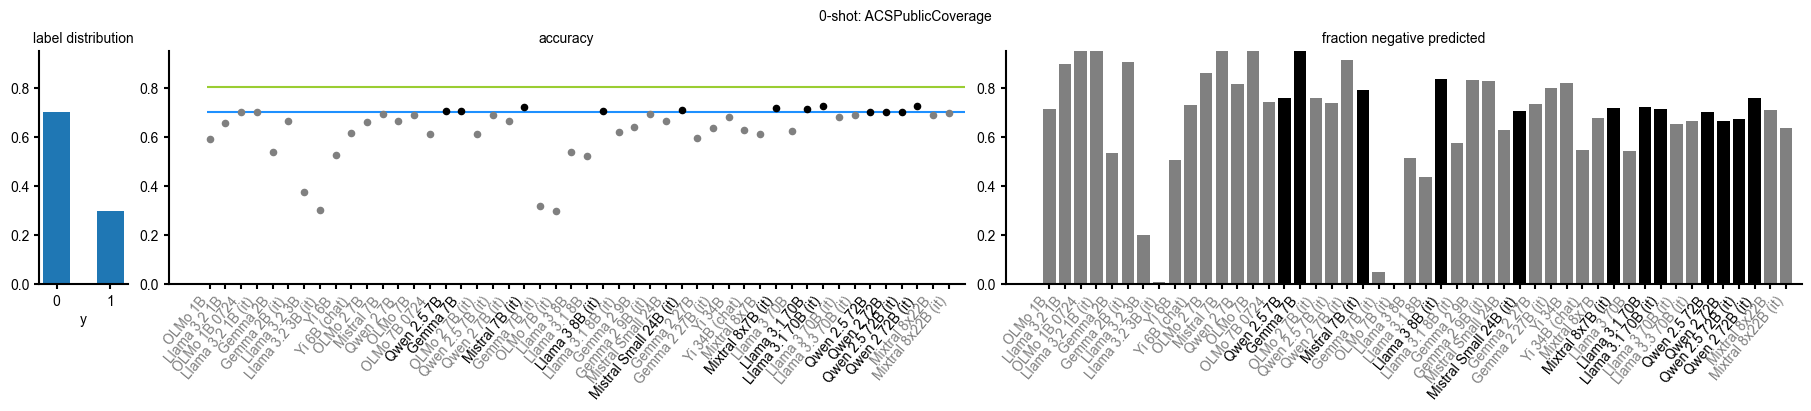

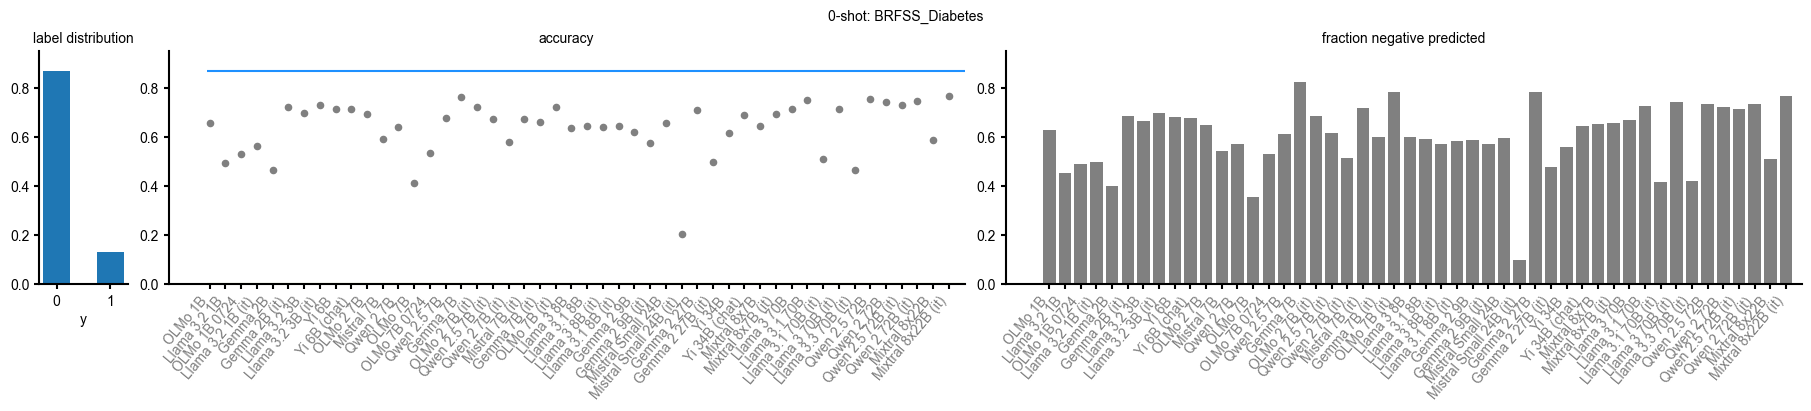

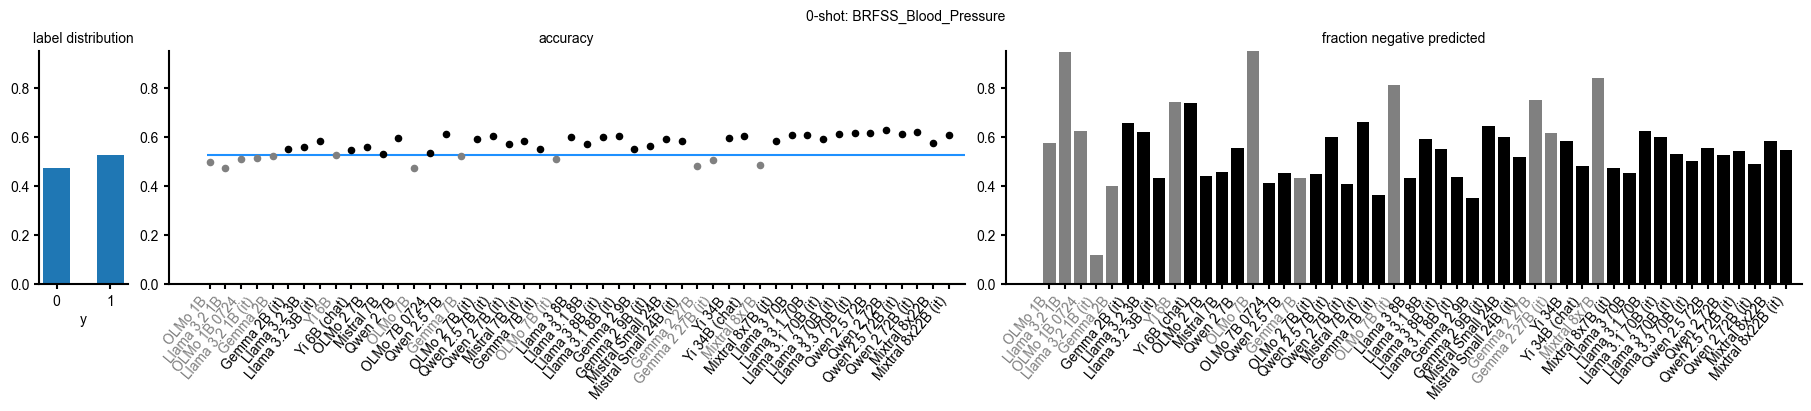

In [19]:
# one plot per task
for task in TASKS:  # , 'ACSEmployment', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure']:
    fig, axs = plt.subplots(
        1,
        3,
        figsize=(18, 4),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1, 9, 9]},
    )
    fig.suptitle(f"0-shot: {task}")
    axs[0].set_title("label distribution")
    axs[1].set_title("accuracy")
    axs[2].set_title("fraction negative predicted")
    pad = 5  # pt
    # axs[0].annotate(task, xy=(0, 0.5), xytext=(-axs[0].yaxis.labelpad - pad, 0), xycoords=axs[0].yaxis.label, textcoords='offset points', size='medium', ha='right', va='center')

    ylims = (0, 0.95)
    # label distribution
    labels = data[task][1]
    axs[0] = plot_label_dist(axs[0], labels, ylims=ylims)

    # model accuracy
    # to exclude constant classifiers: evals = evals_non_const
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_0,
        baseline_evals=baseline_evals,
        models_above_baseline=models_above_baseline_0,
        hline_xmin=-0.2,
        hline_xmax=predictions_0[task].shape[1] + 0.1,
        ylims=ylims,
    )

    # fraction of negative predicted samples
    axs[2] = plot_neg_predicted(
        axs[2],
        task=task,
        evals=evals_0,
        models_above_baseline=models_above_baseline_0,
        omit_non_highlight_labels=False,
        ylims=ylims,
    )

    if task == "ACSIncome":
        axs[1].legend()
    # plt.savefig(RESULTS_ROOT_DIR/f'figures/same_prompt_model_performance_{task}.png')
    plt.show()

#### Before and after calibration (fitting treshold)

In [20]:
df_0 = df[(df["num_shots"] == 0) & (df["threshold_fitted"] == 0)]
df_0_fitted = df[(df["num_shots"] == 0) & (df["threshold_fitted"] == 1)]

# load predictions and measured accuracies
evals_0 = {}
evals_0_fitted = {}
models_above_baseline_0 = {}
models_above_baseline_0_fitted = {}

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
    "threshold",
]
for task in TASKS:
    baseline_acc = baseline_evals[task]["Constant"]["accuracy"]
    print(task)
    task_df = df_0[(df_0["task"] == task)]
    models = task_df["model"].unique().tolist()
    models.sort(key=get_size_and_it)
    models_above_baseline_0[task] = []
    models_above_baseline_0_fitted[task] = []

    evals_0[task] = {}
    for m in models:
        data_m = task_df[task_df["model"] == m]
        assert (
            data_m.shape[0] == 1
        ), f"Expected 1 row for model {m} but found {data_m.shape[0]}\n {data_m}"
        evals_0[task][m] = get_metrics(
            data_m.iloc[0]["eval_results_path"], metrics=metrics
        )
        if evals_0[task][m]["accuracy"] > baseline_acc:
            models_above_baseline_0[task].append(m)

    task_df = df_0_fitted[(df_0_fitted["task"] == task)]
    models = task_df["model"].unique().tolist()
    models.sort(key=get_size_and_it)

    evals_0_fitted[task] = {}
    for m in models:
        data_m = task_df[task_df["model"] == m]
        assert (
            data_m.shape[0] == 1
        ), f"Expected 1 row for model {m} but found {data_m.shape[0]}\n {data_m}"
        evals_0_fitted[task][m] = get_metrics(
            data_m.iloc[0]["eval_results_path"], metrics=metrics
        )
        if evals_0_fitted[task][m]["accuracy"] > baseline_acc:
            models_above_baseline_0_fitted[task].append(m)

ACSIncome
ACSEmployment
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure


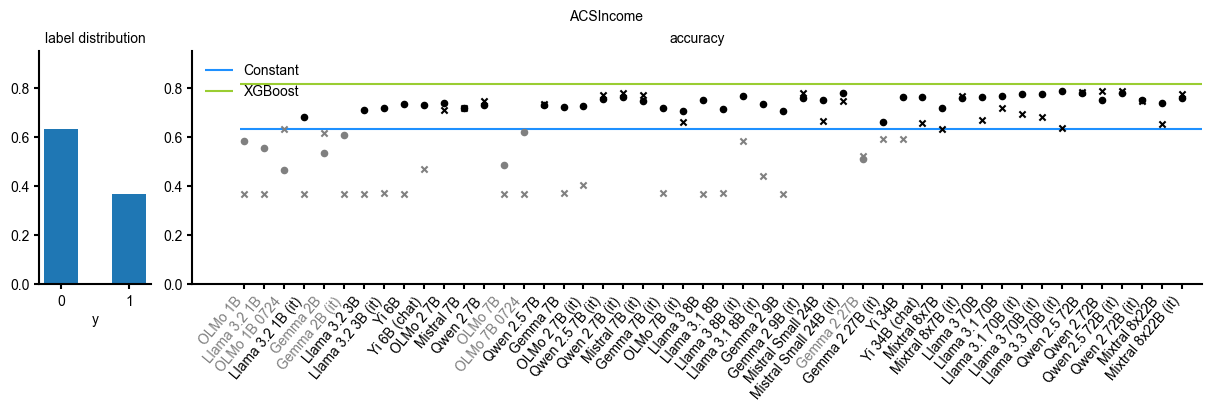

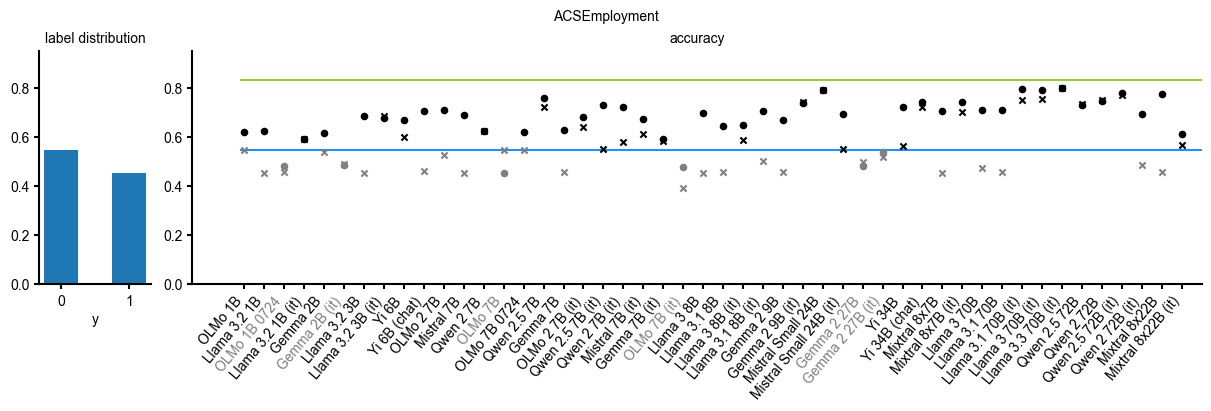

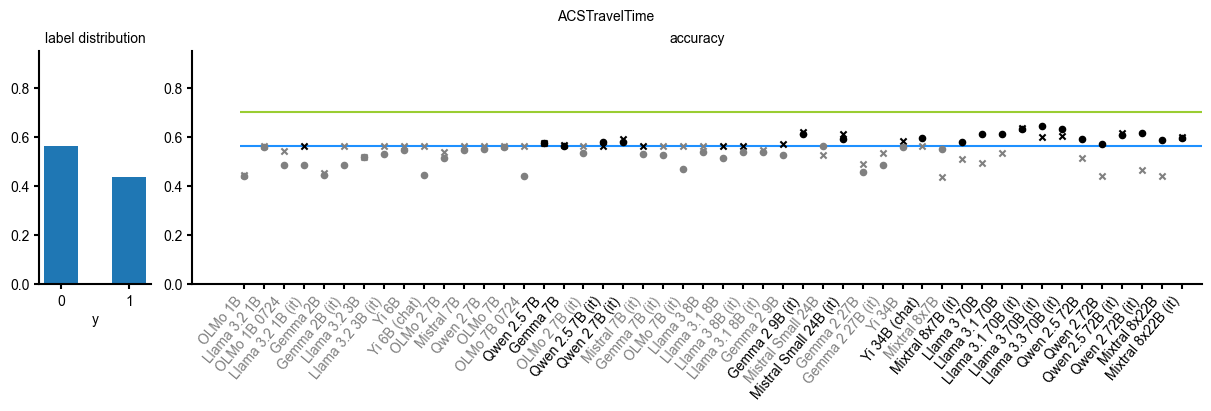

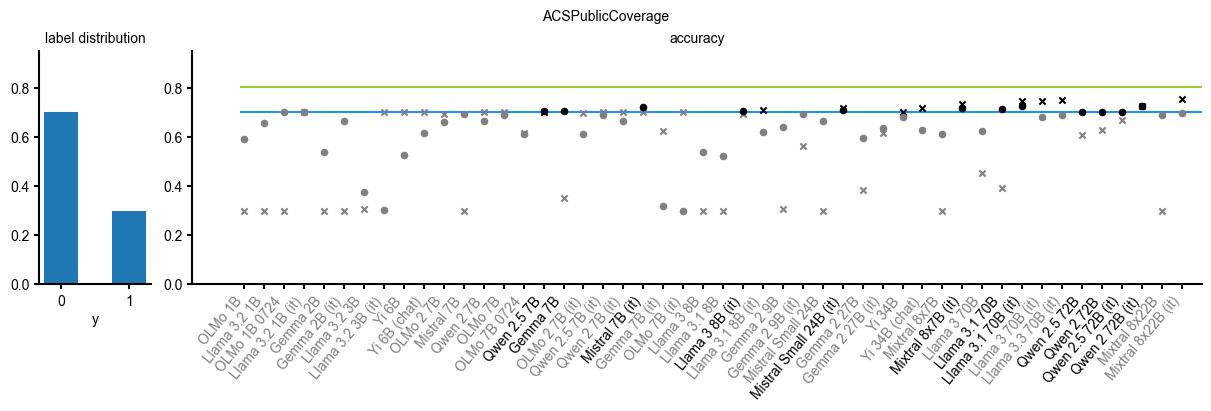

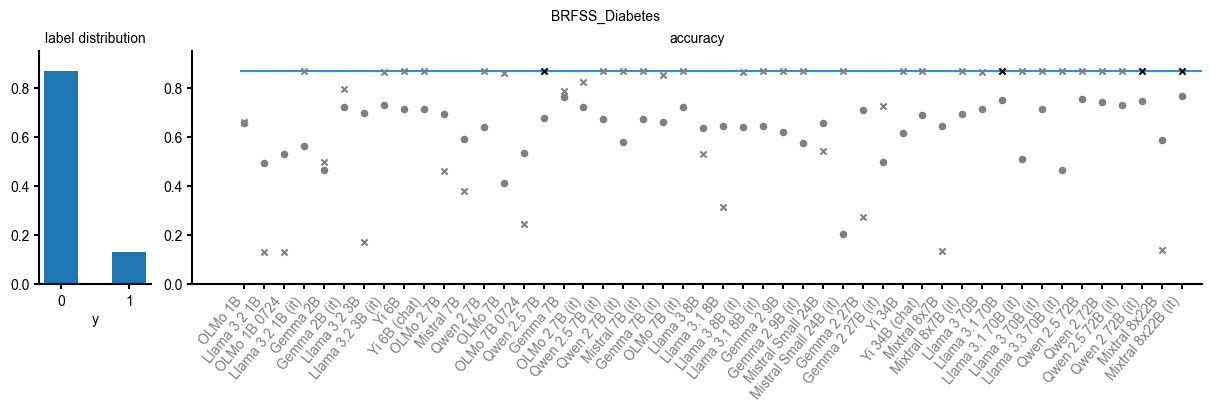

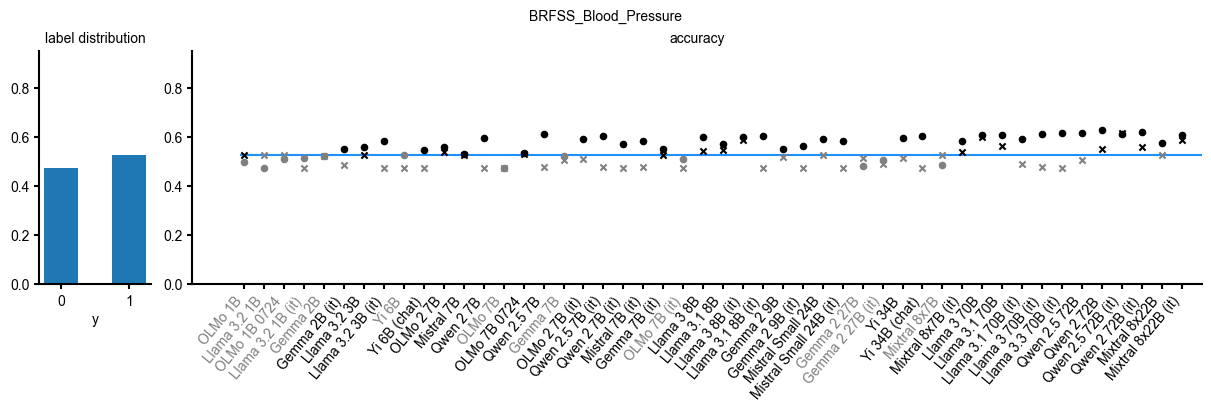

In [21]:
# one plot per task

for i, task in enumerate(
    TASKS
):  # , 'ACSEmployment', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure']:
    fig, axs = plt.subplots(
        1,
        2,
        figsize=(12, 4),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1, 9]},
    )
    fig.suptitle(task)
    axs[0].set_title("label distribution")
    axs[1].set_title("accuracy")
    pad = 5  # pt
    # axs[0].annotate(task, xy=(0, 0.5), xytext=(-axs[0].yaxis.labelpad - pad, 0), xycoords=axs[0].yaxis.label, textcoords='offset points', size='medium', ha='right', va='center')

    ylims = (0, 0.95)
    # label distribution
    labels = data[task][1]
    axs[0] = plot_label_dist(axs[0], labels, ylims=ylims)

    # model accuracy
    # to exclude constant classifiers: evals = evals_non_const
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_0,
        baseline_evals=baseline_evals,
        models_above_baseline={task: models_above_baseline_0[task]},
        hline_xmin=-0.2,
        hline_xmax=predictions_0[task].shape[1] + 0.1,
        ylims=ylims,
        marker="x",
    )
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_0_fitted,
        baseline_evals=None,  # baseline_evals,
        models_above_baseline={task: models_above_baseline_0_fitted[task]},
        ylims=ylims,
        marker="o",
        hline_xmin=-0.2,
        hline_xmax=predictions_0[task].shape[1] + 0.1,
    )

    if task == "ACSIncome":
        axs[1].legend()
    # plt.savefig(RESULTS_ROOT_DIR/f'figures/same_prompt_model_performance_{task}.png')
    plt.show()

In [22]:
for m in evals_0["ACSIncome"].keys():
    print(
        f"- {prettify_model_name(key_to_model(m))+':':<25}{evals_0['ACSIncome'][m]['threshold']}\t{evals_0['ACSIncome'][m]['accuracy']:.2f}"
    )

- OLMo 1B:                 0.5	0.37
- Llama 3.2 1B:            0.5	0.37
- OLMo 1B 0724:            0.5	0.63
- Llama 3.2 1B (it):       0.5	0.37
- Gemma 2B:                0.5	0.62
- Gemma 2B (it):           0.5	0.37
- Llama 3.2 3B:            0.5	0.37
- Llama 3.2 3B (it):       0.5	0.37
- Yi 6B:                   0.5	0.37
- Yi 6B (chat):            0.5	0.47
- OLMo 2 7B:               0.5	0.71
- Mistral 7B:              0.5	0.72
- Qwen 2 7B:               0.5	0.74
- OLMo 7B:                 0.5	0.37
- OLMo 7B 0724:            0.5	0.37
- Qwen 2.5 7B:             0.5	0.74
- Gemma 7B:                0.5	0.37
- OLMo 2 7B (it):          0.5	0.40
- Qwen 2.5 7B (it):        0.5	0.77
- Qwen 2 7B (it):          0.5	0.78
- Mistral 7B (it):         0.5	0.77
- Gemma 7B (it):           0.5	0.37
- OLMo 7B (it):            0.5	0.66
- Llama 3 8B:              0.5	0.37
- Llama 3.1 8B:            0.5	0.37
- Llama 3 8B (it):         0.5	0.58
- Llama 3.1 8B (it):       0.5	0.44
- Gemma 2 9B:              0

#### 10-shot

In [29]:
# load predictions and measured accuracies
predictions_10 = {}
risk_scores_10 = {}
evals_10 = {}

metrics = ["n_samples", "accuracy", "fpr", "num_pred_negatives", "num_pred_positives"]
for task in TASKS[:2]+TASKS[-2:]:
    print(task)
    task_df = df_10[(df_10["task"] == task) & (df_10['threshold_fitted']==0)]

    # available models
    models = task_df["model"].unique().tolist()
    models.sort(key=get_size_and_it)
    predictions_per_task = []
    risk_scores_per_task = []
    evals_10[task] = {}
    for m in models:
        data_m = task_df[task_df["model"] == m]
        assert (
            data_m.shape[0] == 1
        ), f"Expected 1 row for model {m} but found {data_m.shape[0]}, \n {data_m}"
        evals_10[task][m] = get_metrics(
            data_m.iloc[0]["eval_results_path"], metrics=metrics
        )
        predictions_per_task.append(get_predictions(data_m.iloc[0]["predictions_path"]))
        risk_scores_per_task.append(
            load_risk_scores(data_m.iloc[0]["predictions_path"])
        )
    predictions_10[task] = pd.concat(predictions_per_task, axis=1)
    risk_scores_10[task] = pd.concat(risk_scores_per_task, axis=1)

ACSIncome
ACSEmployment
BRFSS_Diabetes
BRFSS_Blood_Pressure


AssertionError: Expected 1 row for model 01-ai--Yi-34B-Chat but found 2, 
                       task               model  is_inst  threshold_fitted  \
1116  BRFSS_Blood_Pressure  01-ai--Yi-34B-Chat        1                 0   
1117  BRFSS_Blood_Pressure  01-ai--Yi-34B-Chat        1                 0   

      bench_hash  num_shots prompt_style prompt_connector  \
1116   128305406         10       bullet               is   
1117   638047386         10       bullet               is   

                                      eval_results_path  \
1116  results/tableshift/10-reuse-bullet-is/model-01...   
1117  results/tableshift/10-reuse-bullet-is/model-01...   

                                       predictions_path  
1116  results/tableshift/10-reuse-bullet-is/model-01...  
1117  results/tableshift/10-reuse-bullet-is/model-01...  

In [ ]:
models_above_baseline_10 = {}
for task in TASKS[:2]+TASKS[-2:]:
    print(task)
    baseline_acc = baseline_evals[task]["Constant"]["accuracy"]
    models_above_baseline_10[task] = [
        model
        for model in sorted(
            predictions_10[task].keys().tolist(),
            key=get_size_and_it,
        )
        if evals_10[task][model]["accuracy"] > baseline_acc
    ]
    print(len(models_above_baseline_10[task]))

ACSIncome
35
ACSEmployment
38


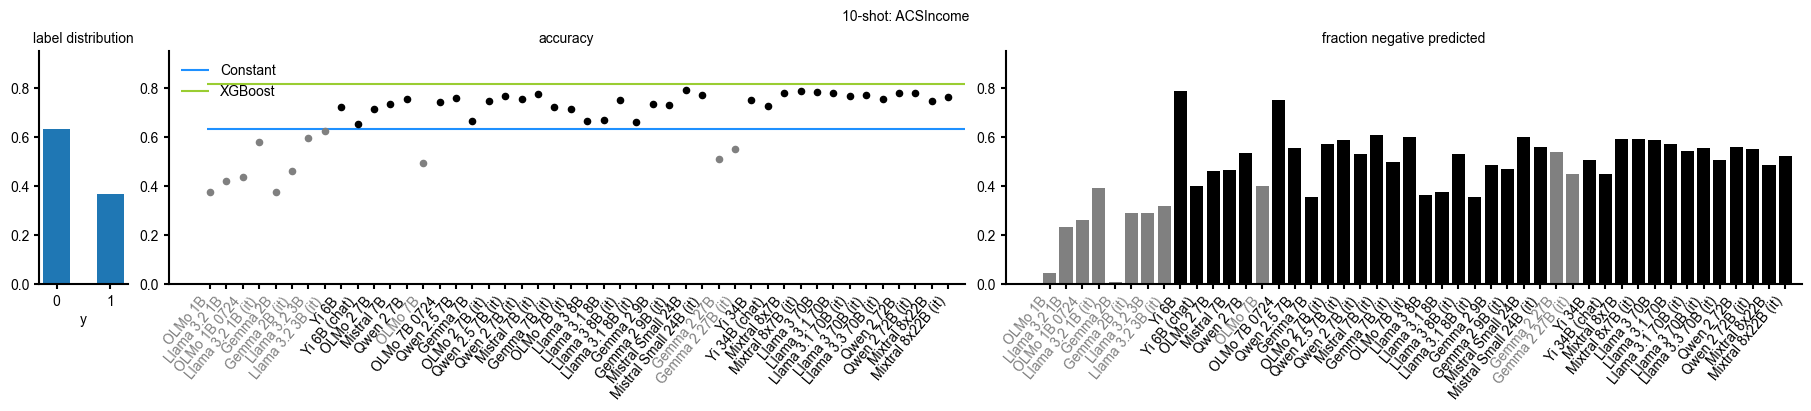

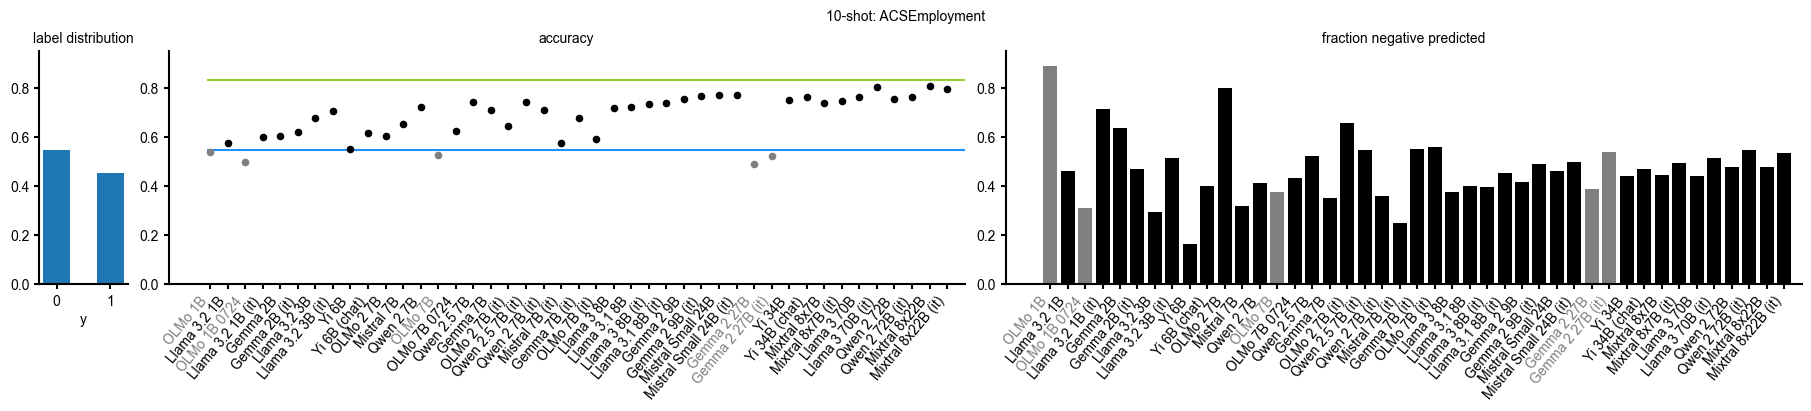

In [25]:
# one plot per task
for task in TASKS[:2]:
    fig, axs = plt.subplots(
        1,
        3,
        figsize=(18, 4),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1, 9, 9]},
    )
    fig.suptitle(f"10-shot: {task}")
    axs[0].set_title("label distribution")
    axs[1].set_title("accuracy")
    axs[2].set_title("fraction negative predicted")
    pad = 5  # pt
    # axs[0].annotate(task, xy=(0, 0.5), xytext=(-axs[0].yaxis.labelpad - pad, 0), xycoords=axs[0].yaxis.label, textcoords='offset points', size='medium', ha='right', va='center')

    ylims = (0, 0.95)
    # label distribution
    labels = data[task][1]
    axs[0] = plot_label_dist(axs[0], labels, ylims=ylims)

    # model accuracy
    # to exclude constant classifiers: evals = evals_non_const
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_10,
        baseline_evals=baseline_evals,
        models_above_baseline=models_above_baseline_10,
        hline_xmin=-0.2,
        hline_xmax=predictions_10[task].shape[1] + 0.1,
        ylims=ylims,
    )
    # axs[1] = plot_accuracies(ax=axs[1], task=task, evals=evals_zeroshot, baseline_evals=baseline_evals, models_above_baseline=models_above_baseline, hline_xmin=-0.2, hline_xmax=predictions[task].shape[1] + 0.1, ylims=ylims)

    # fraction of negative predicted samples
    axs[2] = plot_neg_predicted(
        axs[2],
        task=task,
        evals=evals_10,
        models_above_baseline=models_above_baseline_10,
        omit_non_highlight_labels=False,
        ylims=ylims,
    )

    if task == "ACSIncome":
        axs[1].legend()
    # plt.savefig(RESULTS_ROOT_DIR/f'figures/same_prompt_model_performance_{task}.png')
    plt.show()

##### Risk Scores

In [26]:
base_models_10 = sorted(
    [
        model
        for model in risk_scores_10["BRFSS_Diabetes"].columns
        if not is_instruction_tuned(model)
    ],
    key=get_model_size_B,
)
it_models_10 = sorted(
    [
        model
        for model in risk_scores_10["BRFSS_Diabetes"].columns
        if is_instruction_tuned(model)
    ],
    key=get_model_size_B,
)  # prettify_model_name(key_to_model(model))


# to ensure axis are the same across plots, get max y value per model
ymax = {}
for model in base_models_10:
    ymax[model] = 0
    for task in TASKS:
        N = risk_scores_10[task].shape[0]
        task_max = max(
            np.histogram(
                risk_scores_10[task][model],
                weights=np.zeros((N,)) + 1.0 / N,
                bins=np.arange(0, 1.01, 0.05),
            )[0]
        )
        if task_max > ymax[model]:
            ymax[model] = task_max

for task in TASKS:
    N = risk_scores_10[task].shape[0]
    fig, axs = plt.subplots(2, 6, figsize=(10, 3), constrained_layout=True)
    fig.suptitle(f"10-shot: risk scores on {task}")
    for i, model in enumerate(base_models_10):
        coresponding_it_model = [
            itm
            for itm in it_models_10
            if prettify_model_name(key_to_model(itm)).startswith(
                prettify_model_name(key_to_model(model))
            )
        ]
        # print(model, coresponding_it_model)

        axs[i // 6, i % 6].set_xlim(0.0, 1.0)
        axs[i // 6, i % 6].set_title(prettify_model_name(key_to_model(model)))
        ys, xs, _ = axs[i // 6, i % 6].hist(
            risk_scores_10[task][model],
            weights=np.zeros((N,)) + 1.0 / N,
            alpha=0.75,
            label="base",
            bins=np.arange(0, 1.01, 0.05),
            edgecolor="w",
            linewidth=1,
        )
        axs[i // 6, i % 6].set_ylim(0.0, ymax[model])
        if len(coresponding_it_model) == 1:
            axs[i // 6, i % 6].hist(
                risk_scores_10[task][coresponding_it_model[0]],
                weights=np.zeros((N,)) + 1.0 / N,
                alpha=0.75,
                label="it",
                bins=np.arange(0, 1.01, 0.05),
                edgecolor="w",
                linewidth=1.2,
            )
    axs[-1, -1].legend()
    # plt.savefig(FIGURES_ROOT_DIR/f'{task}_risk_scores.png')

    plt.show()

KeyError: 'BRFSS_Diabetes'

#### Combine plots of 0 and 10 shot

In [ ]:
evals_0_filtered = {
    task: {
        model: v for model, v in evals_0[task].items() if model in evals_10[task].keys()
    }
    for task in TASKS[:2]
}

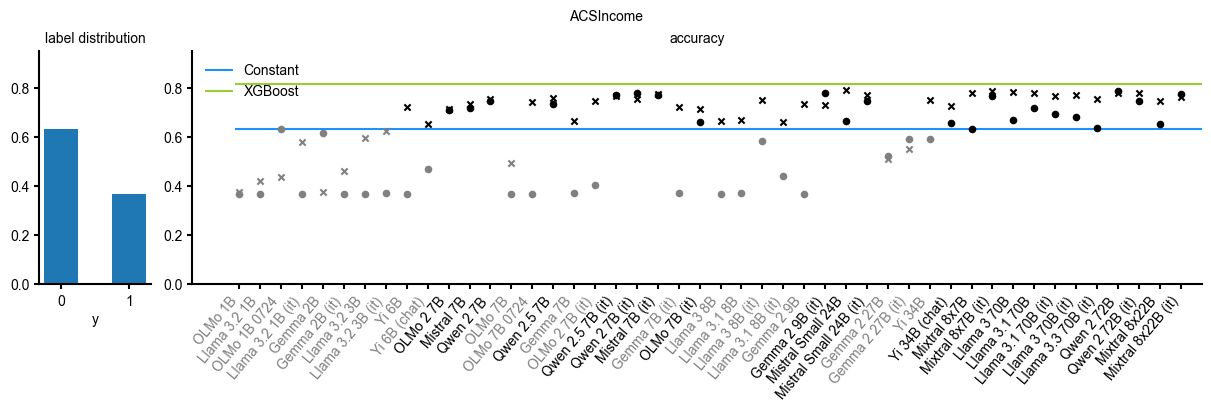

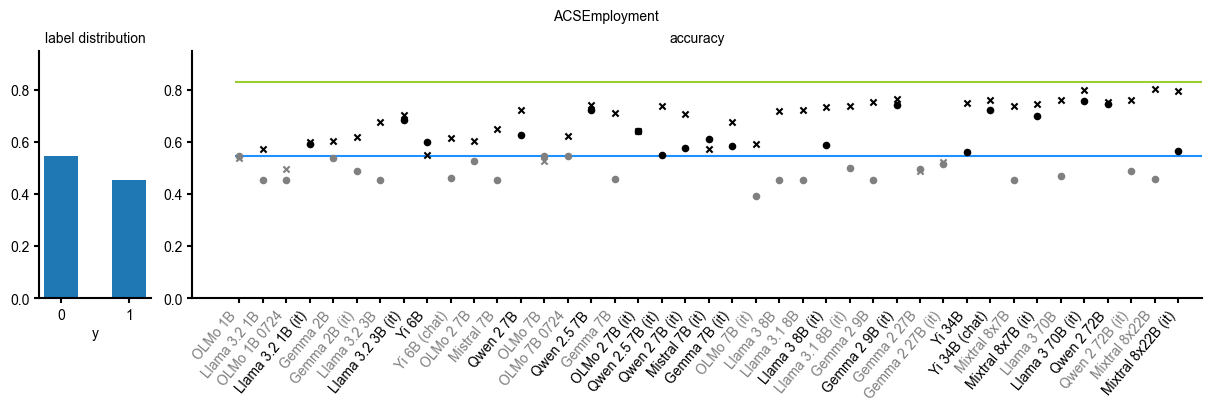

In [ ]:
# one plot per task
for i, task in enumerate(
    TASKS[:2]
):  # , 'ACSEmployment', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure']:
    fig, axs = plt.subplots(
    1,
    2,
    figsize=(12, 4),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1, 9]},
)
    
    fig.suptitle(task)
    axs[0].set_title("label distribution")
    axs[1].set_title("accuracy")
    pad = 5  # pt
    # axs[0].annotate(task, xy=(0, 0.5), xytext=(-axs[0].yaxis.labelpad - pad, 0), xycoords=axs[0].yaxis.label, textcoords='offset points', size='medium', ha='right', va='center')

    ylims = (0, 0.95)
    # label distribution
    labels = data[task][1]
    axs[0] = plot_label_dist(axs[0], labels, ylims=ylims)

    # model accuracy
    # to exclude constant classifiers: evals = evals_non_const
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_10,
        baseline_evals=None,
        models_above_baseline=models_above_baseline_10,
        ylims=ylims,
        marker="x",
    )
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_0_filtered,
        baseline_evals=baseline_evals,
        models_above_baseline=models_above_baseline_0,
        hline_xmin=-0.2,
        hline_xmax=predictions_0[task].shape[1] + 0.1,
        ylims=ylims,
        marker="o",
    )

    if task == "ACSIncome":
        axs[1].legend()
    # plt.savefig(RESULTS_ROOT_DIR/f'figures/same_prompt_model_performance_{task}.png')
    plt.show()